# ASL Alphabet Recognition — Training Notebook

**Model:** MobileNetV2 (Transfer Learning)

**Output:** `asl_model.h5` + `class_names.json`

In [1]:
# INSTALL & IMPORTS
!pip install kagglehub -q

import os, json, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

2026-04-23 20:06:30.593124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776974790.809329      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776974790.873784      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776974791.392461      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776974791.392518      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776974791.392525      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# DOWNLOAD DATASET

import kagglehub
path = kagglehub.dataset_download('grassknoted/asl-alphabet')
print('Dataset path:', path)

# Find the asl_alphabet_train folder
TRAIN_DIR = None
for root, dirs, files in os.walk(path):
    if 'asl_alphabet_train' in dirs:
        TRAIN_DIR = os.path.join(root, 'asl_alphabet_train', 'asl_alphabet_train')
        break
    if os.path.basename(root) == 'asl_alphabet_train':
        TRAIN_DIR = root
        break

print('Train dir:', TRAIN_DIR)
classes = sorted(os.listdir(TRAIN_DIR))
print(f'Classes ({len(classes)}):', classes)

Dataset path: /kaggle/input/datasets/grassknoted/asl-alphabet
Train dir: /kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train
Classes (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [3]:
# MODEL CONFIG
IMG_SIZE   = 128
BATCH_SIZE = 64
EPOCHS_FT  = 10
EPOCHS_UN  = 5
VAL_SPLIT  = 0.15
SEED       = 42

NUM_CLASSES = len(classes)
print(f'Training {NUM_CLASSES} classes at {IMG_SIZE}x{IMG_SIZE}')

Training 29 classes at 128x128


In [4]:
# DATA GENERATORS
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=False,
    brightness_range=[0.8, 1.2],
    shear_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=SEED
)

class_indices = train_gen.class_indices
class_names = {v: k for k, v in class_indices.items()}
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print('Class mapping saved to class_names.json')
print(class_names)

Found 73950 images belonging to 29 classes.
Found 13050 images belonging to 29 classes.
Class mapping saved to class_names.json
{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z', 26: 'del', 27: 'nothing', 28: 'space'}


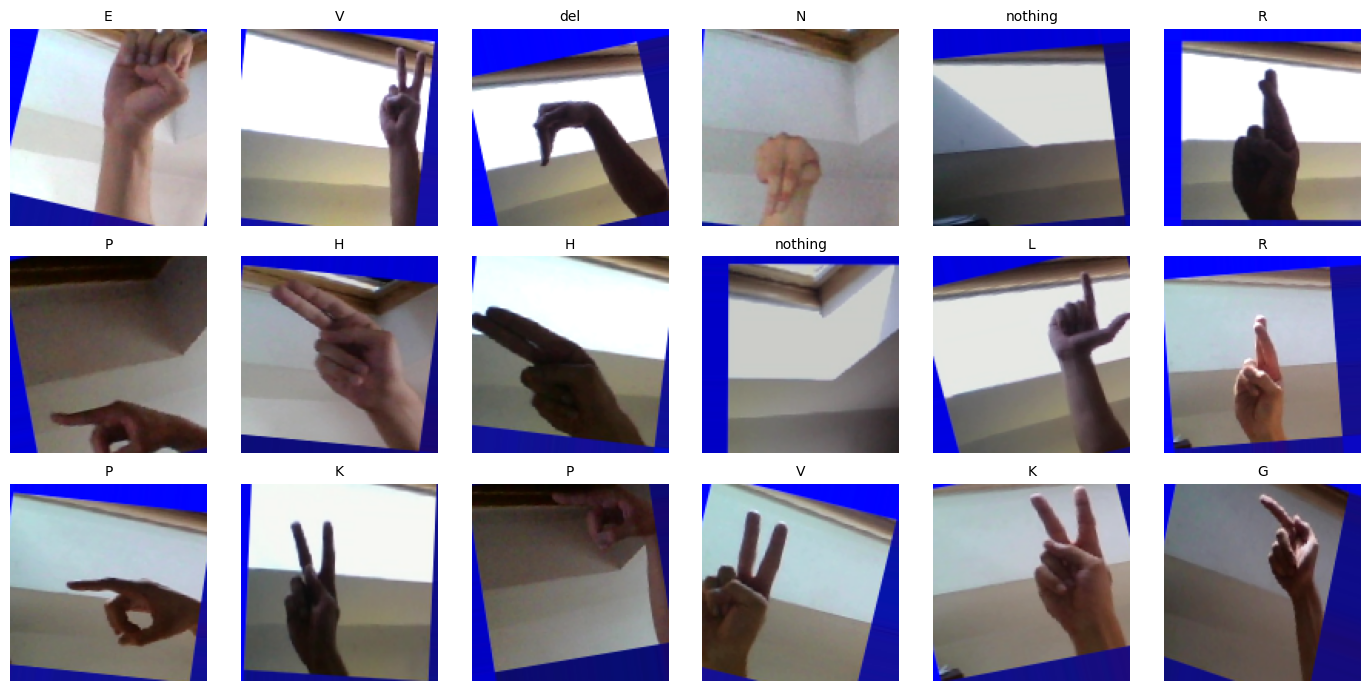

In [5]:
# VISUALIZE SAMPLE IMAGES
batch_x, batch_y = next(train_gen)
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(batch_x[i])
    label_idx = np.argmax(batch_y[i])
    ax.set_title(class_names[label_idx], fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# BUILD MODEL (MobileNetV2 Transfer Learning)
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1776974957.169136      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,057,757 (11.66 MB)

 Trainable params: 797,213 (3.04 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [7]:
# PHASE 1: TRAIN TOP LAYERS (base frozen)
callbacks_phase1 = [
    EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('asl_model_phase1.h5', save_best_only=True, verbose=1)
]

print('Phase 1: Training top layers with frozen base...')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT,
    callbacks=callbacks_phase1
)

Phase 1: Training top layers with frozen base...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1776974982.276735     153 service.cc:152] XLA service 0x7d94940044f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776974982.276784     153 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776974983.842062     153 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776974992.160852     153 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.6891 - loss: 1.0567
Epoch 1: val_loss improved from inf to 0.70126, saving model to asl_model_phase1.h5


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 901s 765ms/step - accuracy: 0.6892 - loss: 1.0563 - val_accuracy: 0.8043 - val_loss: 0.7013 - learning_rate: 0.0010
Epoch 2/10
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8918 - loss: 0.3356
Epoch 2: val_loss did not improve from 0.70126
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 509s 441ms/step - accuracy: 0.8918 - loss: 0.3356 - val_accuracy: 0.8014 - val_loss: 0.7843 - learning_rate: 0.0010
Epoch 3/10
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9131 - loss: 0.2742
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.70126
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 483s 418ms/step - accuracy: 0.9131 - loss: 0.2742 - val_accuracy: 0.8136 - val_loss: 0.7153 - learning_rate: 0.0010
Epoch 4/10
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9334 - loss: 0.2061
Epoch 4: val_loss improved from 0.70126 to 0.69892, saving model to asl_model_phase1.h5


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 553s 478ms/step - accuracy: 0.9334 - loss: 0.2060 - val_accuracy: 0.8299 - val_loss: 0.6989 - learning_rate: 5.0000e-04
Epoch 5/10
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9451 - loss: 0.1698
Epoch 5: val_loss improved from 0.69892 to 0.68231, saving model to asl_model_phase1.h5


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 493s 426ms/step - accuracy: 0.9451 - loss: 0.1698 - val_accuracy: 0.8261 - val_loss: 0.6823 - learning_rate: 5.0000e-04
Epoch 6/10
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9512 - loss: 0.1501
Epoch 6: val_loss did not improve from 0.68231
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 489s 423ms/step - accuracy: 0.9512 - loss: 0.1501 - val_accuracy: 0.8247 - val_loss: 0.7525 - learning_rate: 5.0000e-04
Epoch 7/10
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9530 - loss: 0.1440
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 7: val_loss did not improve from 0.68231
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 509s 441ms/step - accuracy: 0.9530 - loss: 0.1440 - val_accuracy: 0.8294 - val_loss: 0.7201 - learning_rate: 5.0000e-04
Epoch 8/10
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9583 - loss: 0.1273
Epoch 8: val_loss did not improve from 0.68231
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 517s 447ms/step - accuracy: 

In [8]:
# PHASE 2: FINE-TUNE (unfreeze top 30 layers)
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # Lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('asl_model.h5', save_best_only=True, verbose=1)
]

print('Phase 2: Fine-tuning top layers of base model...')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_UN,
    callbacks=callbacks_phase2
)

Phase 2: Fine-tuning top layers of base model...
Epoch 1/5


2026-04-23 21:35:58.606832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 21:35:58.803845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 478/1156 ━━━━━━━━━━━━━━━━━━━━ 4:34 405ms/step - accuracy: 0.8652 - loss: 0.4558

2026-04-23 21:39:22.588516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 21:39:22.785744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8995 - loss: 0.3346
Epoch 1: val_loss improved from inf to 0.78683, saving model to asl_model.h5


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 528s 439ms/step - accuracy: 0.8996 - loss: 0.3345 - val_accuracy: 0.8200 - val_loss: 0.7868 - learning_rate: 1.0000e-04
Epoch 2/5
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9700 - loss: 0.0970
Epoch 2: val_loss improved from 0.78683 to 0.69689, saving model to asl_model.h5


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 477s 413ms/step - accuracy: 0.9700 - loss: 0.0970 - val_accuracy: 0.8570 - val_loss: 0.6969 - learning_rate: 1.0000e-04
Epoch 3/5
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9800 - loss: 0.0627
Epoch 3: val_loss improved from 0.69689 to 0.68841, saving model to asl_model.h5


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 475s 411ms/step - accuracy: 0.9800 - loss: 0.0627 - val_accuracy: 0.8704 - val_loss: 0.6884 - learning_rate: 1.0000e-04
Epoch 4/5
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9839 - loss: 0.0502
Epoch 4: val_loss improved from 0.68841 to 0.47766, saving model to asl_model.h5


1156/1156 ━━━━━━━━━━━━━━━━━━━━ 469s 406ms/step - accuracy: 0.9839 - loss: 0.0502 - val_accuracy: 0.8907 - val_loss: 0.4777 - learning_rate: 1.0000e-04
Epoch 5/5
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9871 - loss: 0.0418
Epoch 5: val_loss did not improve from 0.47766
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 548s 474ms/step - accuracy: 0.9871 - loss: 0.0418 - val_accuracy: 0.8786 - val_loss: 0.5967 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 4.


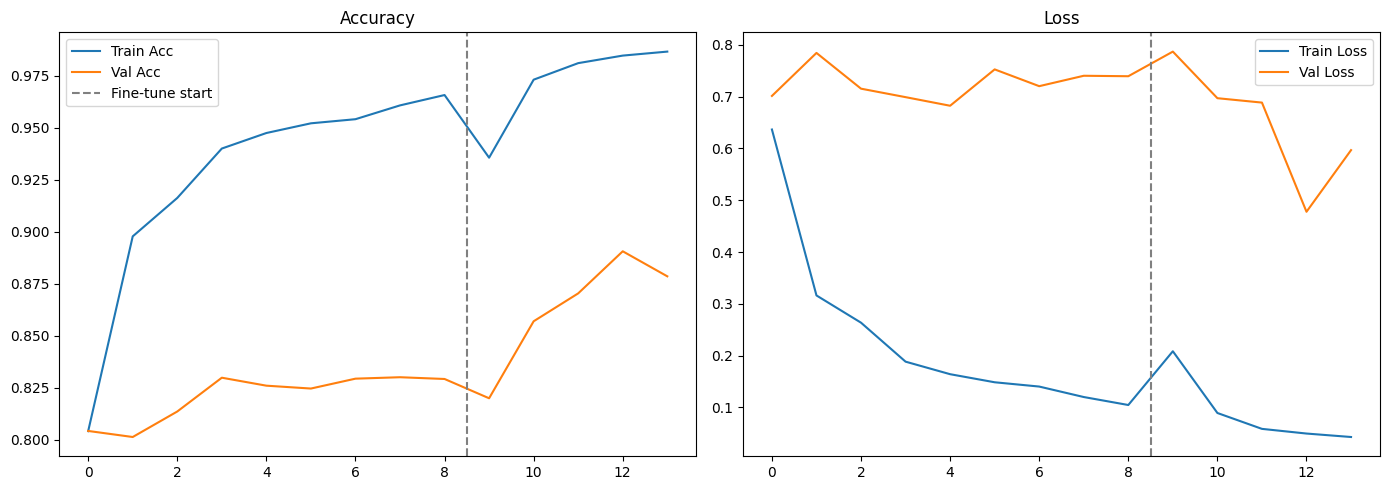

In [13]:
# PLOT TRAINING HISTORY
def plot_history(h1, h2):
    acc  = h1.history['accuracy']  + h2.history['accuracy']
    vacc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    vloss= h1.history['val_loss'] + h2.history['val_loss']
    ep   = range(len(acc))
    split= len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(ep, acc, label='Train Acc'); ax1.plot(ep, vacc, label='Val Acc')
    ax1.axvline(split - 0.5, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set_title('Accuracy'); ax1.legend()
    ax2.plot(ep, loss, label='Train Loss'); ax2.plot(ep, vloss, label='Val Loss')
    ax2.axvline(split - 0.5, color='gray', linestyle='--')
    ax2.set_title('Loss'); ax2.legend()
    plt.tight_layout(); plt.savefig('training_history.png', dpi=300)
    plt.show()

plot_history(history1, history2)

204/204 ━━━━━━━━━━━━━━━━━━━━ 33s 161ms/step

Classification Report:
              precision    recall  f1-score   support

           A       0.04      0.04      0.04       450
           B       0.04      0.04      0.04       450
           C       0.03      0.03      0.03       450
           D       0.03      0.03      0.03       450
           E       0.02      0.02      0.02       450
           F       0.04      0.04      0.04       450
           G       0.04      0.04      0.04       450
           H       0.04      0.05      0.04       450
           I       0.03      0.03      0.03       450
           J       0.05      0.04      0.05       450
           K       0.04      0.03      0.03       450
           L       0.04      0.04      0.04       450
           M       0.04      0.05      0.04       450
           N       0.05      0.02      0.03       450
           O       0.04      0.03      0.03       450
           P       0.03      0.03      0.03       450
           Q 

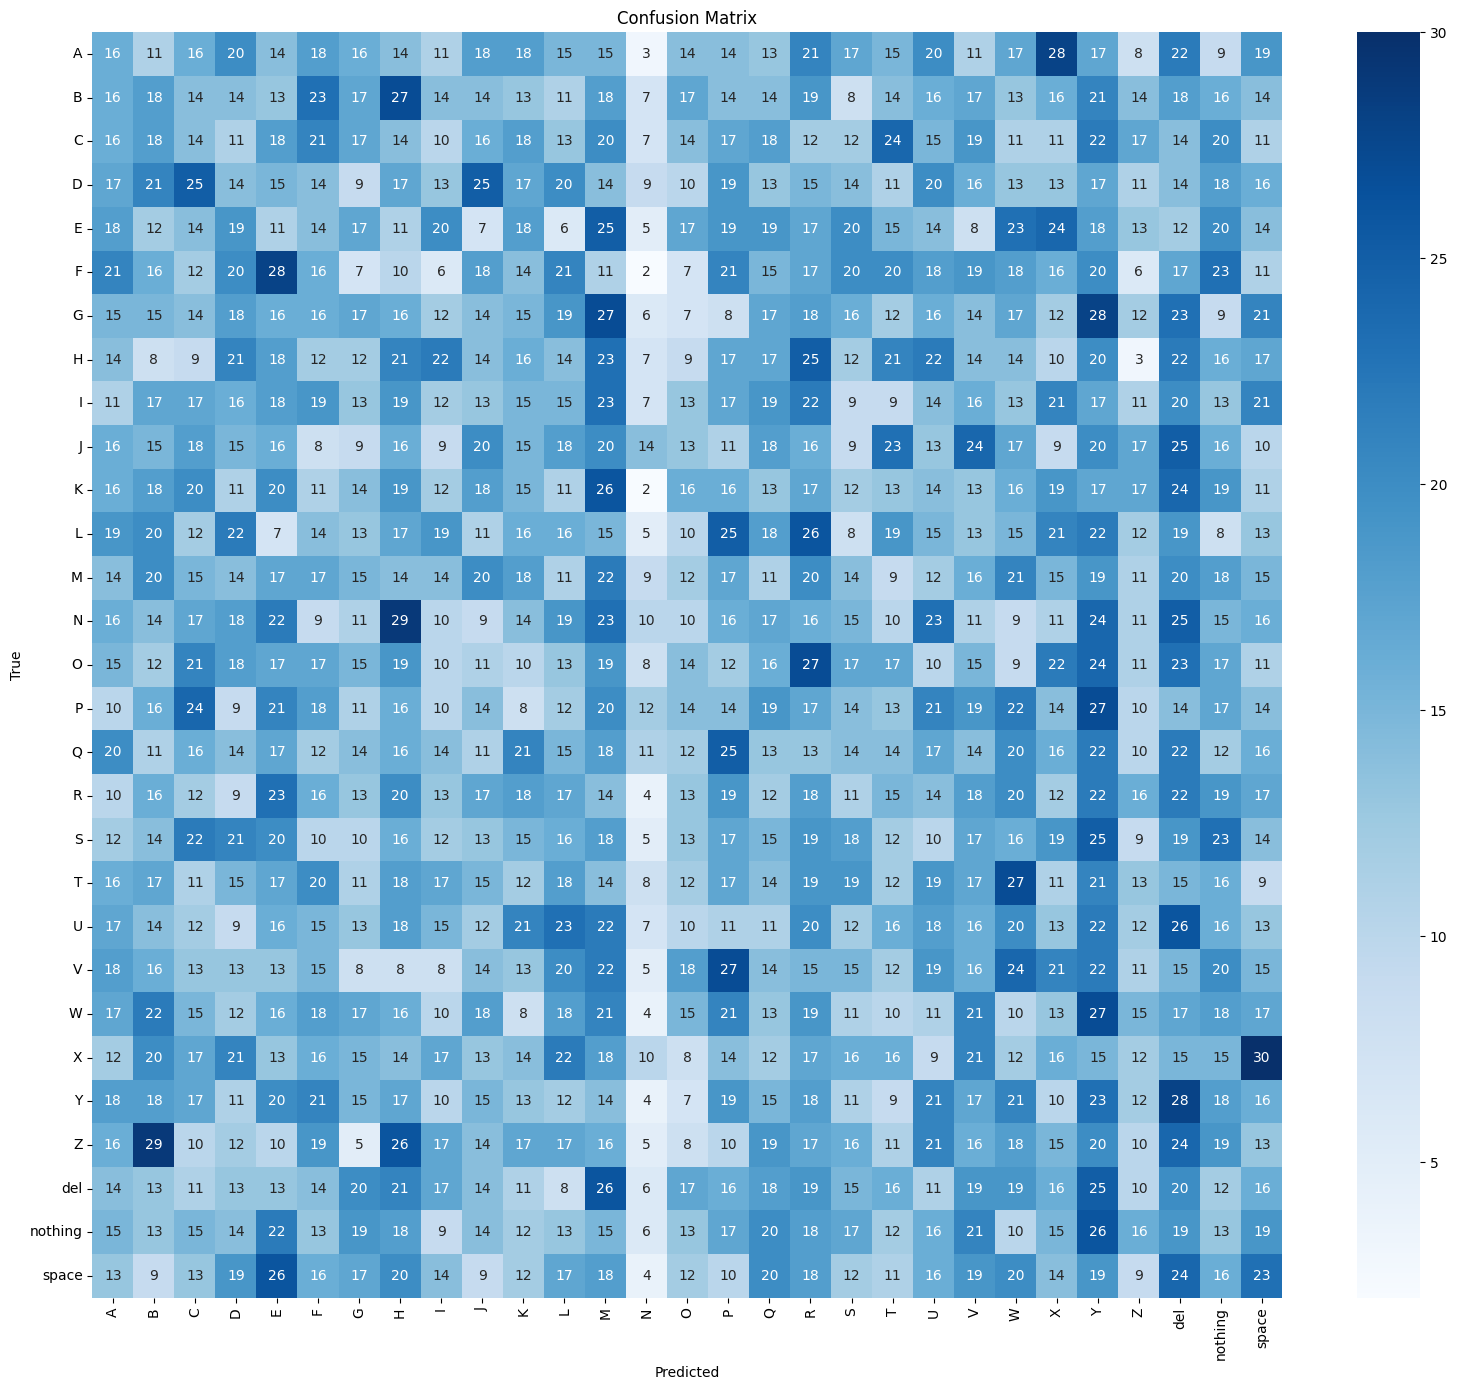

In [12]:
# EVALUATE & CONFUSION MATRIX
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_gen.reset()
y_pred = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred_classes,
      target_names=[class_names[i] for i in range(NUM_CLASSES)]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

In [11]:
# SAVE FINAL MODEL
model.save('asl_model.h5')
print('✅ Model saved: asl_model.h5')
print('✅ Labels saved: class_names.json')
print()
print('Download both files and use them with the webcam detection app!')

# Export to TFLite for faster inference
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('asl_model.tflite', 'wb') as f:
    f.write(tflite_model)
print('✅ TFLite model saved: asl_model.tflite (smaller & faster)')

✅ Model saved: asl_model.h5
✅ Labels saved: class_names.json

Download both files and use them with the webcam detection app!
INFO:tensorflow:Assets written to: /tmp/tmp6djxrt1o/assets


INFO:tensorflow:Assets written to: /tmp/tmp6djxrt1o/assets


Saved artifact at '/tmp/tmp6djxrt1o'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 29), dtype=tf.float32, name=None)
Captures:
  138080602015696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266359888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266363728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266363344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266360464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266363920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266362384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266364496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266364112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266362192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138078266

W0000 00:00:1776982857.265624      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776982857.265676      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776982857.448484      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
